In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../Data/AIML Dataset.csv")
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df[df["isFraud"] == 1].head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0
251,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,0
252,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,0
680,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,0


KIỂM TRA CẤU TRÚC DỮ LIỆU CƠ BẢN CỦA TẬP DỮ LIỆU

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [6]:
df.columns
df.shape

(6362620, 11)

In [7]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [8]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [9]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [10]:
df.shape

(6362620, 11)

In [11]:
fraud_rate = round((df["isFraud"].value_counts()[1]/df.shape[0])*100,2)
print(fraud_rate)

0.13


TRỰC QUAN HÓA DỮ LIỆU

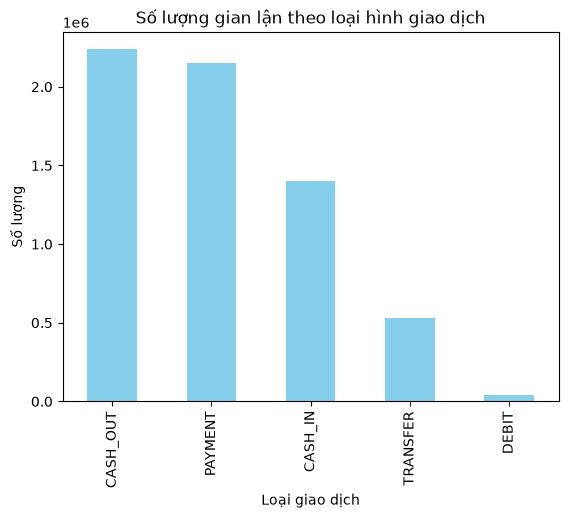

In [12]:
df["type"].value_counts().plot(kind="bar", title= "Số lượng gian lận theo loại hình giao dịch", color="skyblue")
plt.xlabel("Loại giao dịch")
plt.ylabel("Số lượng")

plt.show()

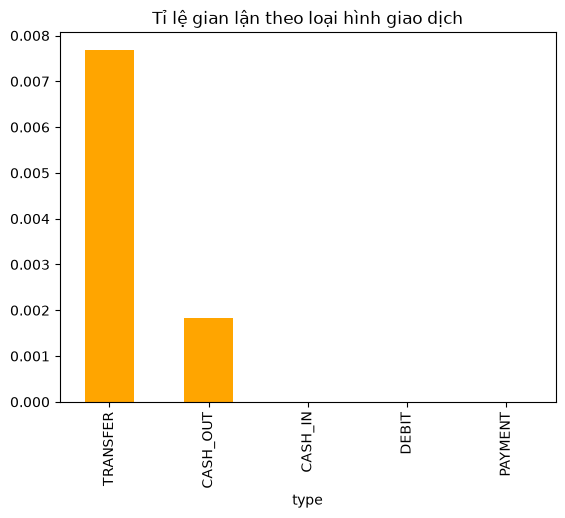

In [13]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending= False)     ##Tỉ lệ dựa trên giá trị mean
fraud_by_type.plot(kind="bar", title="Tỉ lệ gian lận theo loại hình giao dịch", color = "Orange")  

plt.show()

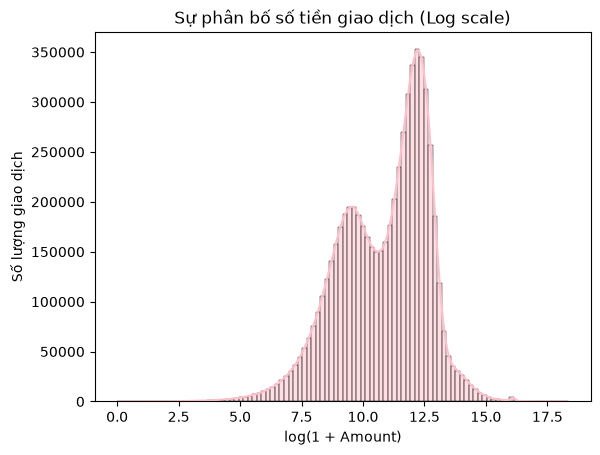

In [14]:
sns.histplot(np.log1p(df["amount"]), bins= 100, kde= True, color="pink")
plt.title("Sự phân bố số tiền giao dịch (Log scale)")
plt.xlabel("log(1 + Amount)")
plt.ylabel("Số lượng giao dịch")

plt.show()

In [15]:
log_amount = np.log1p(df["amount"])
print(f"Log_min = {log_amount.min()} and Log_max = {round(log_amount.max(),2)}")
print(log_amount.value_counts())

Log_min = 0.0 and Log_max = 18.34
amount
16.118096    3207
9.210440       88
8.517393       79
9.615872       68
6.216606       65
             ... 
11.977849       1
12.134978       1
11.315662       1
15.805609       1
15.551502       1
Name: count, Length: 5316900, dtype: int64


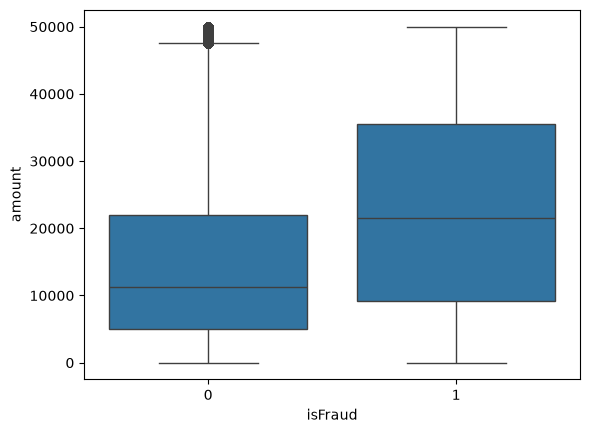

In [16]:
sns.boxplot(x="isFraud", y="amount", data=df[df["amount"] < 50000])
plt.show()

KIỂM TRA CÁC DỊ THƯỜNG VÀ CHUỖI CÂN BẰNG

In [17]:
df["balanceDiffOrg"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrg,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,9839.64,0.00
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,1864.28,0.00
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,181.00,0.00
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,181.00,-21182.00
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,11668.14,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,339682.13,339682.13
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,6311409.28,0.00
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,6311409.28,6311409.27
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,850002.52,0.00


In [18]:
print((df["balanceDiffOrg"] < 0).sum(), (df["balanceDiffDest"] < 0).sum())

1399253 1238864


step
1      16
2       8
3       4
4      10
5       6
       ..
739    10
740     6
741    22
742    14
743     8
Name: count, Length: 741, dtype: int64


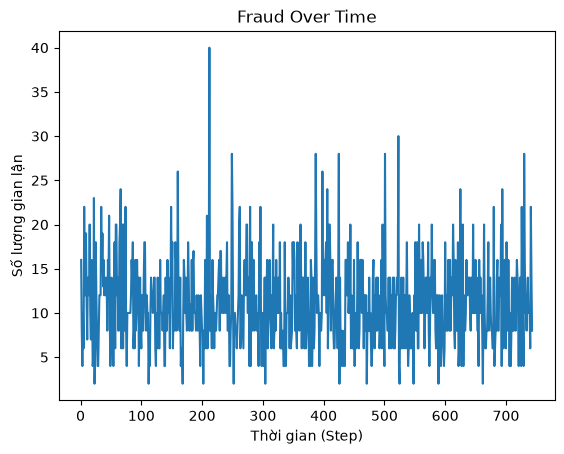

In [19]:
fraud_per_step = df[df["isFraud"]==1]["step"].value_counts().sort_index()
print(fraud_per_step)

plt.plot(fraud_per_step.index, fraud_per_step.values, label = "Fraud per step")
plt.xlabel("Thời gian (Step)")
plt.ylabel("Số lượng gian lận")
plt.title("Fraud Over Time")
plt.show()

In [20]:
df.drop(columns="step", inplace= True)

In [21]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrg,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


KIỂM TRA DỮ LIỆU GIAO DỊCH Ở PHÍA KHÁCH HÀNG

In [22]:
top_senders = df["nameOrig"].value_counts().head(10)

In [23]:
top_senders

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

In [24]:
top_receivers = df["nameDest"].value_counts().head(10)

In [25]:
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [26]:
fraud_users = df[df["isFraud"] ==1]["nameOrig"].value_counts().head(10)

In [27]:
fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [28]:
fraud_type = df[df["type"].isin(["TRANSFER","CASH_OUT"])]

In [29]:
fraud_type["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

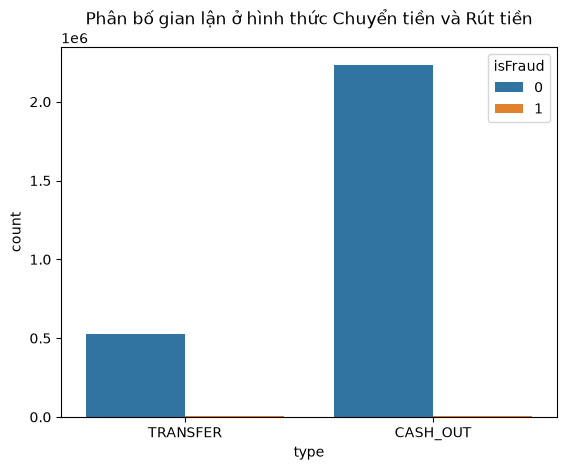

In [30]:
sns.countplot(data= fraud_type, x="type", hue="isFraud")
plt.title("Phân bố gian lận ở hình thức Chuyển tiền và Rút tiền")
plt.show()

In [31]:
corr = df[["amount", "oldbalanceOrg","newbalanceOrig", "oldbalanceDest","newbalanceDest","isFraud"]].corr()

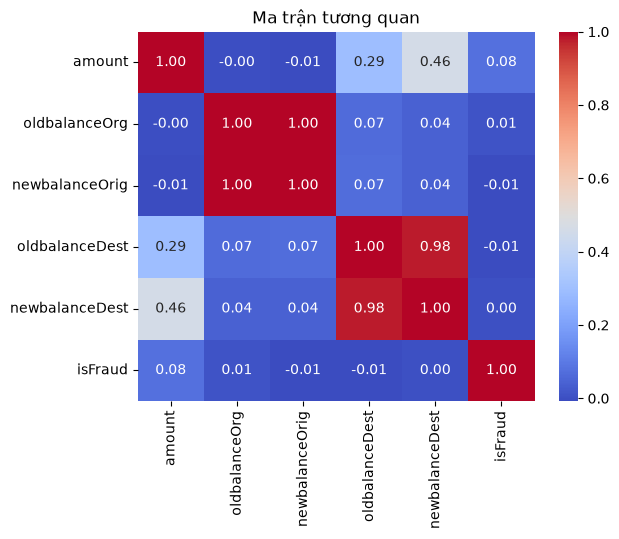

In [32]:
sns.heatmap(data=corr, annot=True, cmap = 'coolwarm', fmt='.2f')
plt.title("Ma trận tương quan")
plt.show()

In [33]:
zero_after_transfer = df [
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(['TRANSFER', 'CASH_OUT']))
]

In [34]:
zero_after_transfer

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrg,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,181.00,0.00
3,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,181.00,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0,15325.00,46430.44
19,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0,705.00,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0,10835.00,2712905.89
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,339682.13,339682.13
6362616,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,6311409.28,0.00
6362617,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,6311409.28,6311409.27
6362618,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,850002.52,0.00


FEATURING ENGINEERING & TRAINING A ML MODEL

In [35]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [5]:
df["amountBalanceRatio"] = (df["amount"] / (df["oldbalanceOrg"] + 1))

In [6]:
df["balanceErrorOrg"] = abs(
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"])

In [7]:
df["balanceErrorDest"] = abs(
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
#%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrg,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [11]:
df_model = df.drop(["nameOrig","nameDest","isFlaggedFraud"], axis=1)

In [12]:
df_model.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,amountBalanceRatio,balanceErrorOrg,balanceErrorDest
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0.057834,0.0,9839.64
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0.087731,0.0,1864.28
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0.994505,0.0,181.00
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0.994505,0.0,21363.00
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0.280788,0.0,11668.14


In [13]:
categortical = ["type"]
numeric = ["amount", "oldbalanceOrg","newbalanceOrig", "oldbalanceDest", "newbalanceDest","balanceDiffOrg","balanceDiffDest",
           "amountBalanceRatio","balanceErrorOrg", "balanceErrorDest"]

In [14]:
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis=1)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,stratify=y, random_state=42)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),numeric),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"),categortical)
    ],
    remainder="drop"
)

In [ ]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
       n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced",
        #max_samples=0.3,
        n_jobs=-1,
        random_state=42))
])

In [ ]:
pipeline.fit(X_train, y_train)

In [ ]:
y_pred = pipeline.predict(X_test)

In [ ]:
y_prob = pipeline.predict_proba(X_test)[:, 1] #diem du doan cho lop Fraud

In [16]:
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.25      0.99      0.40      2464

    accuracy                           1.00   1908786
   macro avg       0.63      0.99      0.70   1908786
weighted avg       1.00      1.00      1.00   1908786



In [ ]:
confusion_matrix(y_test,y_pred)

array([[1899031,    7291],
       [     28,    2436]])

In [ ]:
#AUPRC càng cao → model càng có khả năng phân biệt Fraud với Normal trong một dataset mất cân bằng.
auprc = average_precision_score(
    y_test,
    y_prob
)

print(f"AUPRC: {auprc:.4f}")

In [ ]:
pipeline.score(X_test,y_test) * 100

99.61656256908842

In [ ]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Precision-Recall Curve - Random Forest")
plt.show()

In [ ]:
import joblib

joblib.dump(pipeline, "FraudDetectionPipeline_RF.pkl")

['FraudDetectionPipeline_RF.pkl']